# Economic Significance V5 - Lump Sum Timing con Semnal V5
**Scenariu:** Ai $10.000 cash. SP500 a cazut. Cand investesti?

**Investitor A (Immediate):** Investeste imediat cand SP500 cade X% fata de maxim (trigger)

**Investitor B (V5 Timed):** Asteapta semnalul V5 (P >= threshold), investeste la prima confirmare

**Masuram:** Pretul de intrare si valoarea dupa 3, 6, 12 luni per criza

**De ce e relevant pentru paper:** Demonstreaza ca modelul identifica un punct de intrare
mai bun decat un investitor care reactioneaza imediat la cadere

## 1. Import si Incarcare Model

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, pickle, os, warnings
warnings.filterwarnings('ignore')
from fredapi import Fred

os.makedirs('plots', exist_ok=True)
os.makedirs('data',  exist_ok=True)

ensemble = pickle.load(open('../V5/models/v5_ensemble.pkl', 'rb'))
scaler   = pickle.load(open('../V5/models/v5_scaler.pkl',   'rb'))

with open('../V5/models/v5_model_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS      = meta['feature_cols']
OPTIMAL_THRESHOLD = meta['optimal_threshold']
LUMP_SUM          = 10000   # $10.000 investiti

# Trigger: cand SP500 cade cu X% fata de maximul recent
TRIGGER_DROP = 0.10   # -10% declanseaza scenariul

print('Model:', meta['model_name'], '| AUC:', meta['auc'])
print('Threshold V5:', OPTIMAL_THRESHOLD)
print('Lump Sum:', '$' + str(LUMP_SUM))
print('Trigger cadere:', str(int(TRIGGER_DROP*100)) + '%')

Model: Voting Ensemble | AUC: 0.804
Threshold V5: 0.62
Lump Sum: $10000
Trigger cadere: 10%


## 2. FRED API Key

In [2]:
FRED_API_KEY = '9cbb31e1e8aeea0f649895cfc852dce7'
fred = Fred(api_key=FRED_API_KEY)
print('FRED API conectat.')

FRED API conectat.


## 3. Crize de Testat

Definim exact ziua de trigger per criza (prima zi in care SP500 a cazut 10%+ fata de maxim)
si perioada de analiza post-intrare.

In [3]:
# Fiecare criza: trigger_date = prima zi de -10%, end = sfarsitul ferestrei de analiza
CRISES = [
    {
        'name'        : 'COVID Crash 2020',
        'trigger_date': '2020-02-27',   # prima zi -10% fata de maxim febr 2020
        'end_date'    : '2021-02-27',   # 12 luni dupa trigger
        'category'    : 'Black Swan'
    },
    {
        'name'        : 'Fed Rate Hikes 2022',
        'trigger_date': '2022-01-24',   # prima zi -10% fata de maxim ian 2022
        'end_date'    : '2023-01-24',
        'category'    : 'Grey Swan'
    },
    {
        'name'        : 'Liberation Day 2025',
        'trigger_date': '2025-04-04',   # prima zi -10% dupa anuntul tarifelor
        'end_date'    : '2026-04-04',
        'category'    : 'Grey Swan'
    },
    {
        'name'        : 'Q4 2018 Correction',
        'trigger_date': '2018-12-07',   # prima zi -10% in corectia din Q4 2018
        'end_date'    : '2019-12-07',
        'category'    : 'Grey Swan'
    },
]

print('Crize de analizat:')
for c in CRISES:
    print(' ', c['category'].ljust(12), c['name'])
    print('    Trigger:', c['trigger_date'], '| Analiza pana la:', c['end_date'])

Crize de analizat:
  Black Swan   COVID Crash 2020
    Trigger: 2020-02-27 | Analiza pana la: 2021-02-27
  Grey Swan    Fed Rate Hikes 2022
    Trigger: 2022-01-24 | Analiza pana la: 2023-01-24
  Grey Swan    Liberation Day 2025
    Trigger: 2025-04-04 | Analiza pana la: 2026-04-04
  Grey Swan    Q4 2018 Correction
    Trigger: 2018-12-07 | Analiza pana la: 2019-12-07


## 4. Descarcare Date SP500 + VIX + Macro

In [4]:
START_DATA   = '2016-01-01'
END_DATA     = '2026-04-14'

sp500 = yf.download('^GSPC', start=START_DATA, end=END_DATA, auto_adjust=True)
sp500 = sp500[['Close', 'Volume']].copy()
sp500.columns = ['SP500_Close', 'SP500_Volume']

vix = yf.download('^VIX', start=START_DATA, end=END_DATA, auto_adjust=True)
vix = vix[['Close']].copy()
vix.columns = ['VIX_raw']

daily = sp500.join(vix, how='left')
daily.index = pd.to_datetime(daily.index)

FALLBACK_VALUES = {
    'Yield_Curve': 0.50, 'Jobless_Claims': 300000,
    'Credit_Spread': 3.50, 'Dollar_Index': 90.0, 'Fed_Rate': 2.50
}
fred_series = {
    'Yield_Curve'   : ['T10Y2Y', 'T10Y3M', 'DGS10'],
    'Jobless_Claims': ['ICSA', 'IC4WSA'],
    'Credit_Spread' : ['BAMLH0A0HYM2', 'BAMLC0A0CBBB'],
    'Dollar_Index'  : ['DTWEXM', 'DTWEXBGS'],
    'Fed_Rate'      : ['FEDFUNDS', 'DFF', 'DFEDTARU']
}

macro_raw = pd.DataFrame()
for name, codes in fred_series.items():
    success = False
    for code in codes:
        try:
            series = fred.get_series(code, observation_start=START_DATA, observation_end=END_DATA)
            if series.dropna().empty:
                continue
            series.name = name
            macro_raw = macro_raw.join(series, how='outer') if not macro_raw.empty else series.to_frame()
            print(name.ljust(20), '| OK:', code, '| Ultima val:', round(series.dropna().iloc[-1], 3))
            success = True
            break
        except:
            continue
    if not success:
        macro_raw[name] = FALLBACK_VALUES.get(name, 0.0)
        print(name.ljust(20), '| FALLBACK')

macro_raw.index = pd.to_datetime(macro_raw.index)
macro_raw = macro_raw.ffill().bfill()
print('\nDate descarcate:', daily.index[0].date(), '->', daily.index[-1].date())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Yield_Curve          | OK: T10Y2Y | Ultima val: 0.52
Jobless_Claims       | OK: ICSA | Ultima val: 219000.0
Credit_Spread        | OK: BAMLH0A0HYM2 | Ultima val: 2.94
Dollar_Index         | OK: DTWEXM | Ultima val: 90.822
Fed_Rate             | OK: FEDFUNDS | Ultima val: 3.64

Date descarcate: 2016-01-04 -> 2026-04-13


## 5. Feature Engineering + Semnal V5 Saptamanal

In [5]:
df = daily.join(macro_raw, how='left').ffill().bfill()

df['MA50']             = df['SP500_Close'].rolling(50).mean()
df['MA200']            = df['SP500_Close'].rolling(200).mean()
df['Dist_MA50']        = (df['SP500_Close'] - df['MA50'])  / df['MA50']
df['Dist_MA200']       = (df['SP500_Close'] - df['MA200']) / df['MA200']
df['Dist_52w_High']    = (df['SP500_Close'] - df['SP500_Close'].rolling(252).max()) / df['SP500_Close'].rolling(252).max()
df['Return_1d']        = df['SP500_Close'].pct_change()
df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)
df['Local_Min_20d']    = df['SP500_Close'].rolling(20).min()
df['Dist_Local_Min']   = (df['SP500_Close'] - df['Local_Min_20d']) / df['Local_Min_20d']
df['VIX_MA60']         = df['VIX_raw'].rolling(60).mean()
df['VIX_Ratio']        = df['VIX_raw'] / df['VIX_MA60']

delta = df['SP500_Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss))

def rolling_slope(series, window):
    slopes = [np.nan] * len(series)
    vals, x = series.values, np.arange(window)
    for i in range(window - 1, len(vals)):
        y = vals[i - window + 1 : i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(x, y, 1)[0]
    return pd.Series(slopes, index=series.index)

df['VIX_Trend_20d']      = rolling_slope(df['VIX_raw'], 20)
df['SP500_Trend_20d']    = rolling_slope(df['SP500_Close'], 20)
df['Yield_Curve_Change'] = df['Yield_Curve'].diff(20)
df['Jobless_MA12']       = df['Jobless_Claims'].rolling(60).mean()
df['Jobless_Ratio']      = df['Jobless_Claims'] / df['Jobless_MA12']
df['Dollar_Change']      = df['Dollar_Index'].pct_change(4).fillna(0.0)

agg_rules = {
    'SP500_Close': 'last', 'SP500_Volume': 'sum', 'VIX_raw': 'mean',
    'Dist_MA50': 'last', 'Dist_MA200': 'last', 'Dist_52w_High': 'last',
    'RSI': 'last', 'Dist_Local_Min': 'last', 'VIX_Ratio': 'mean',
    'VIX_Trend_20d': 'mean', 'SP500_Trend_20d': 'last',
    'Realized_Vol_10d': 'mean', 'Yield_Curve': 'mean',
    'Yield_Curve_Change': 'last', 'Jobless_Ratio': 'mean', 'Dollar_Change': 'last'
}
for col in ['Credit_Spread', 'Fed_Rate']:
    if col in df.columns:
        agg_rules[col] = 'mean' if col == 'Credit_Spread' else 'last'

weekly = df.resample('W-FRI').agg(agg_rules)
weekly = weekly.rename(columns={'VIX_raw': 'VIX'})
weekly['Return_1w']    = weekly['SP500_Close'].pct_change()
weekly['Return_4w']    = weekly['SP500_Close'].pct_change(4)
weekly['Volume_Ratio'] = weekly['SP500_Volume'] / weekly['SP500_Volume'].rolling(8).mean()
weekly = weekly.loc[:, ~weekly.columns.duplicated()]
for col, val in [('Credit_Spread', 3.50), ('Fed_Rate', 2.50)]:
    if col not in weekly.columns:
        weekly[col] = val
weekly = weekly.ffill()
weekly.dropna(subset=['Return_1w'], inplace=True)
weekly['Phase'] = 1

# Semnal V5 pe tot istoricul
X_all = pd.DataFrame(
    np.zeros((len(weekly), len(FEATURE_COLS))),
    columns=FEATURE_COLS, index=weekly.index
)
for col in FEATURE_COLS:
    if col in weekly.columns:
        X_all[col] = weekly[col].fillna(0.0).values

proba_all = ensemble.predict_proba(scaler.transform(X_all.values))[:, 1]
weekly['P_VShape'] = proba_all
weekly['Signal']   = (proba_all >= OPTIMAL_THRESHOLD).astype(int)

print('Semnal V5 calculat pe', len(weekly), 'saptamani.')
print('Saptamani cu semnal V-shape:', weekly['Signal'].sum(),
      '(' + str(round(weekly['Signal'].mean()*100,1)) + '%)')

Semnal V5 calculat pe 536 saptamani.
Saptamani cu semnal V-shape: 41 (7.6%)


## 6. Simulare Lump Sum Timing per Criza

**Logica:**
- Investitor A (Immediate): cumpara la pretul din `trigger_date`
- Investitor B (V5 Timed): asteapta primul semnal V5 dupa `trigger_date`, cumpara la acel pret
- Masuram valoarea investitiei dupa 3, 6, 12 luni

In [6]:
HORIZONS = [13, 26, 52]   # 3 luni, 6 luni, 12 luni in saptamani

results = []

for crisis in CRISES:
    trigger = pd.to_datetime(crisis['trigger_date'])
    end     = pd.to_datetime(crisis['end_date'])

    # Gasim saptamana de trigger in weekly
    trigger_week = weekly[weekly.index >= trigger].index[0] if (weekly.index >= trigger).any() else None
    if trigger_week is None:
        print('SKIP:', crisis['name'], '- trigger date not in data')
        continue

    # Pretul la trigger (Investitor A)
    price_A = float(weekly.loc[trigger_week, 'SP500_Close'])

    # Primul semnal V5 dupa trigger (Investitor B)
    post_trigger = weekly[(weekly.index >= trigger_week) & (weekly.index <= end)]
    v5_weeks     = post_trigger[post_trigger['Signal'] == 1]

    if len(v5_weeks) == 0:
        print(crisis['name'], '| Niciun semnal V5 in fereastra - folosim trigger')
        entry_week_B = trigger_week
        weeks_waited = 0
    else:
        entry_week_B = v5_weeks.index[0]
        weeks_waited = len(weekly[(weekly.index >= trigger_week) & (weekly.index < entry_week_B)])

    price_B = float(weekly.loc[entry_week_B, 'SP500_Close'])

    # Shares cumparate
    shares_A = LUMP_SUM / price_A
    shares_B = LUMP_SUM / price_B

    # Valori dupa 3, 6, 12 luni
    row = {
        'Crisis'        : crisis['name'],
        'Category'      : crisis['category'],
        'Trigger Date'  : trigger_week.date(),
        'Price A ($)'   : round(price_A, 2),
        'Entry B Date'  : entry_week_B.date(),
        'Price B ($)'   : round(price_B, 2),
        'Weeks Waited'  : weeks_waited,
        'Price Diff ($)': round(price_A - price_B, 2),
        'Price Diff (%)': round((price_A - price_B) / price_A * 100, 2),
    }

    for h in HORIZONS:
        future_idx = weekly[weekly.index >= trigger_week].index
        if len(future_idx) > h:
            future_price = float(weekly.iloc[weekly.index.get_loc(trigger_week) + h]['SP500_Close'])
        else:
            future_price = float(weekly['SP500_Close'].iloc[-1])

        val_A = shares_A * future_price
        val_B = shares_B * future_price
        ret_A = round((val_A - LUMP_SUM) / LUMP_SUM * 100, 2)
        ret_B = round((val_B - LUMP_SUM) / LUMP_SUM * 100, 2)
        label = str(h // 4) + 'm' if h < 52 else '12m'

        row['Val A ' + label + ' ($)']   = round(val_A, 0)
        row['Val B ' + label + ' ($)']   = round(val_B, 0)
        row['Return A ' + label + ' (%)'] = ret_A
        row['Return B ' + label + ' (%)'] = ret_B
        row['Alpha ' + label + ' (%)']    = round(ret_B - ret_A, 2)

    results.append(row)
    print(crisis['name'])
    print('  Investitor A (Immediate): pret $' + str(round(price_A,2)) + ' pe', str(trigger_week.date()))
    print('  Investitor B (V5 Timed):  pret $' + str(round(price_B,2)) + ' pe', str(entry_week_B.date()),
          '(dupa', weeks_waited, 'saptamani)')
    print('  Diferenta pret: $' + str(round(price_A - price_B,2)),
          '(' + str(round((price_A-price_B)/price_A*100,2)) + '% mai ieftin pentru B)')
    print()

results_df = pd.DataFrame(results)
results_df.to_csv('data/lump_sum_timing_results.csv', index=False)

COVID Crash 2020
  Investitor A (Immediate): pret $2954.22 pe 2020-02-28
  Investitor B (V5 Timed):  pret $2954.22 pe 2020-02-28 (dupa 0 saptamani)
  Diferenta pret: $0.0 (0.0% mai ieftin pentru B)

Fed Rate Hikes 2022
  Investitor A (Immediate): pret $4431.85 pe 2022-01-28
  Investitor B (V5 Timed):  pret $4431.85 pe 2022-01-28 (dupa 0 saptamani)
  Diferenta pret: $0.0 (0.0% mai ieftin pentru B)

Liberation Day 2025
  Investitor A (Immediate): pret $5074.08 pe 2025-04-04
  Investitor B (V5 Timed):  pret $5363.36 pe 2025-04-11 (dupa 1 saptamani)
  Diferenta pret: $-289.28 (-5.7% mai ieftin pentru B)

Q4 2018 Correction | Niciun semnal V5 in fereastra - folosim trigger
Q4 2018 Correction
  Investitor A (Immediate): pret $2633.08 pe 2018-12-07
  Investitor B (V5 Timed):  pret $2633.08 pe 2018-12-07 (dupa 0 saptamani)
  Diferenta pret: $0.0 (0.0% mai ieftin pentru B)



## 7. Tabel Comparativ

In [7]:
print('LUMP SUM TIMING - $' + str(LUMP_SUM) + ' INVESTITI')
print('=' * 80)
print()

cols_show = ['Crisis', 'Price A ($)', 'Price B ($)', 'Price Diff (%)', 'Weeks Waited']
for h in HORIZONS:
    label = str(h//4) + 'm' if h < 52 else '12m'
    cols_show += ['Return A ' + label + ' (%)', 'Return B ' + label + ' (%)', 'Alpha ' + label + ' (%)']

print(results_df[cols_show].to_string(index=False))
print()
print('Price Diff (%) pozitiv = Investitor B a cumparat mai ieftin')
print('Alpha pozitiv = Investitor B a obtinut return mai mare')
print()

# Statistici agregate
for h in HORIZONS:
    label = str(h//4) + 'm' if h < 52 else '12m'
    alpha_col = 'Alpha ' + label + ' (%)'
    if alpha_col in results_df.columns:
        mean_alpha = results_df[alpha_col].mean()
        pos_alpha  = (results_df[alpha_col] > 0).sum()
        print('Orizont', label.ljust(4),
              '| Alpha mediu:', str(round(mean_alpha,2)).rjust(7), '%',
              '| Crize cu alpha pozitiv:', pos_alpha, '/', len(results_df))

LUMP SUM TIMING - $10000 INVESTITI

             Crisis  Price A ($)  Price B ($)  Price Diff (%)  Weeks Waited  Return A 3m (%)  Return B 3m (%)  Alpha 3m (%)  Return A 6m (%)  Return B 6m (%)  Alpha 6m (%)  Return A 12m (%)  Return B 12m (%)  Alpha 12m (%)
   COVID Crash 2020      2954.22      2954.22             0.0             0             3.05             3.05          0.00            18.75            18.75          0.00             29.01             29.01            0.0
Fed Rate Hikes 2022      4431.85      4431.85             0.0             0            -6.77            -6.77          0.00            -6.80            -6.80          0.00             -8.15             -8.15            0.0
Liberation Day 2025      5074.08      5363.36            -5.7             1            23.75            17.08         -6.67            32.35            25.22         -7.13             29.73             22.73           -7.0
 Q4 2018 Correction      2633.08      2633.08             0.0           

## 8. Grafic Principal

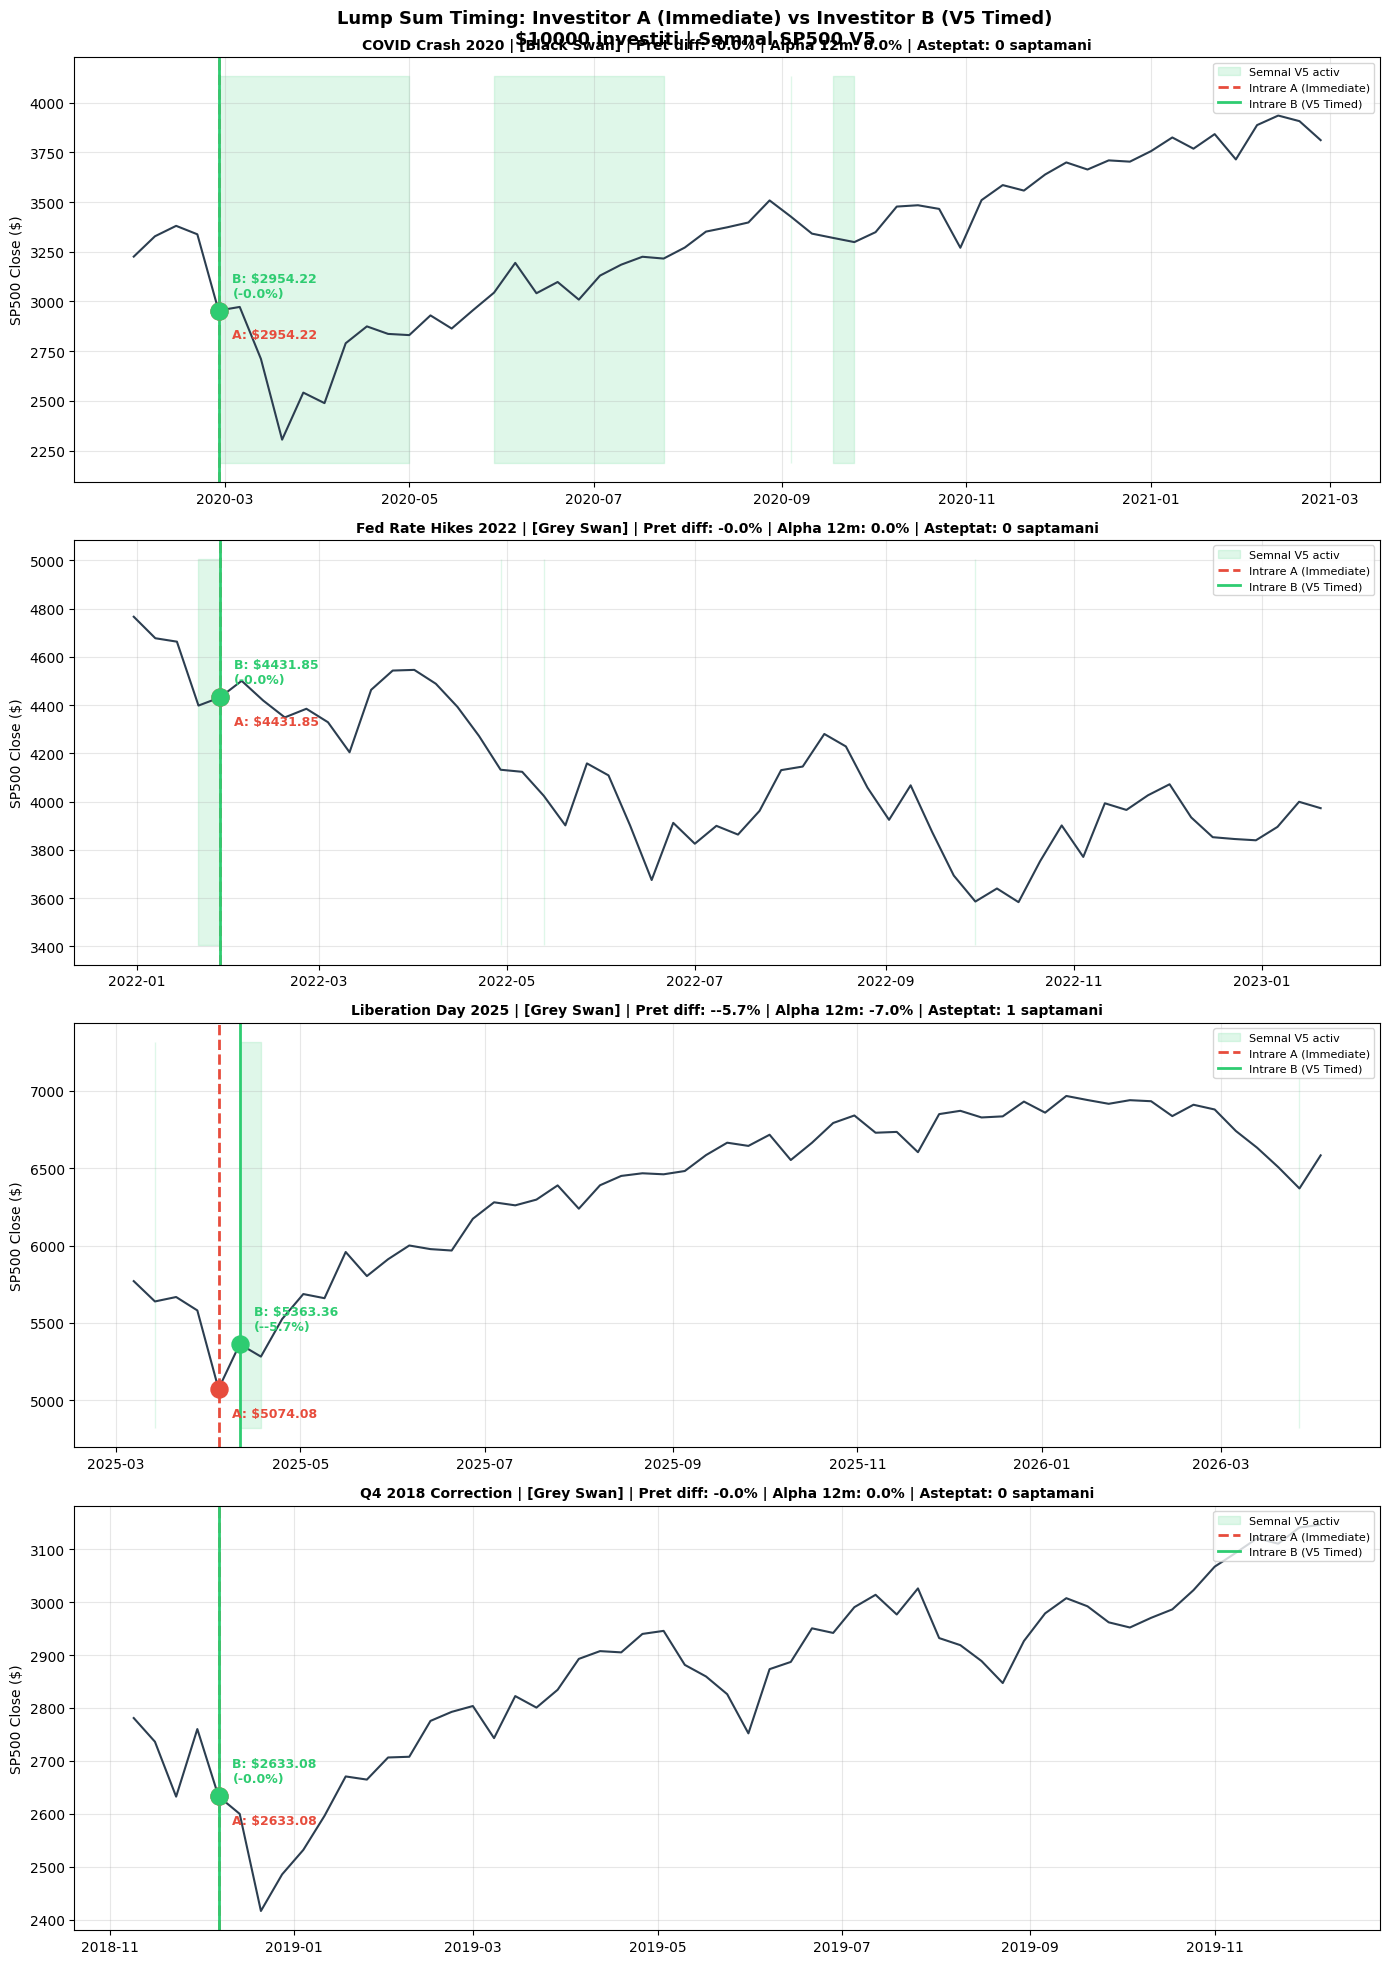

Salvat: plots/lump_sum_timing.png


In [8]:
fig, axes = plt.subplots(len(CRISES), 1, figsize=(14, 5 * len(CRISES)))
if len(CRISES) == 1:
    axes = [axes]

colors_horizon = {'3m': '#3498db', '6m': '#2ecc71', '12m': '#e67e22'}

for idx, (crisis, row) in enumerate(zip(CRISES, results)):
    ax       = axes[idx]
    trigger  = pd.to_datetime(crisis['trigger_date'])
    end      = pd.to_datetime(crisis['end_date'])

    mask   = (weekly.index >= trigger - pd.Timedelta(weeks=4)) & (weekly.index <= end)
    prices = weekly.loc[mask, 'SP500_Close']
    signal = weekly.loc[mask, 'Signal']
    proba  = weekly.loc[mask, 'P_VShape']

    # Pretul SP500
    ax.plot(prices.index, prices.values, color='#2c3e50', linewidth=1.5, zorder=3)

    # Zona verde = semnal V5 activ
    ax.fill_between(prices.index, prices.min()*0.95, prices.max()*1.05,
                    where=signal.reindex(prices.index, fill_value=0) == 1,
                    alpha=0.15, color='#2ecc71', label='Semnal V5 activ')

    # Marcam intrarile
    price_A  = row['Price A ($)']
    price_B  = row['Price B ($)']
    date_A   = pd.to_datetime(row['Trigger Date'])
    date_B   = pd.to_datetime(row['Entry B Date'])

    ax.axvline(date_A, color='#e74c3c', linewidth=2, linestyle='--', label='Intrare A (Immediate)')
    ax.axvline(date_B, color='#2ecc71', linewidth=2, linestyle='-',  label='Intrare B (V5 Timed)')
    ax.scatter([date_A], [price_A], color='#e74c3c', s=150, zorder=5)
    ax.scatter([date_B], [price_B], color='#2ecc71', s=150, zorder=5)

    # Adnotari
    ax.annotate('A: $' + str(price_A), (date_A, price_A),
                textcoords='offset points', xytext=(10, -20),
                fontsize=9, color='#e74c3c', fontweight='bold')
    ax.annotate('B: $' + str(price_B) + '\n(-' + str(row['Price Diff (%)']) + '%)',
                (date_B, price_B),
                textcoords='offset points', xytext=(10, 10),
                fontsize=9, color='#2ecc71', fontweight='bold')

    ax.set_ylabel('SP500 Close ($)')
    alpha_12 = row.get('Alpha 12m (%)', 'N/A')
    ax.set_title(
        crisis['name'] + ' | [' + crisis['category'] + ']' +
        ' | Pret diff: -' + str(row['Price Diff (%)']) + '%' +
        ' | Alpha 12m: ' + str(alpha_12) + '%' +
        ' | Asteptat: ' + str(row['Weeks Waited']) + ' saptamani',
        fontsize=10, fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Lump Sum Timing: Investitor A (Immediate) vs Investitor B (V5 Timed)\n' +
             '$' + str(LUMP_SUM) + ' investiti | Semnal SP500 V5',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/lump_sum_timing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/lump_sum_timing.png')

## 9. Fraze pentru Paper

In [ ]:
separator = '=' * 65
print('FRAZE PENTRU PAPER')
print(separator)
print()

if len(results_df) > 0:
    alpha_12_mean = results_df['Alpha 12m (%)'].mean() if 'Alpha 12m (%)' in results_df.columns else 'N/A'
    pos_12        = (results_df['Alpha 12m (%)'] > 0).sum() if 'Alpha 12m (%)' in results_df.columns else 'N/A'
    mean_waited   = results_df['Weeks Waited'].mean()
    mean_diff     = results_df['Price Diff (%)'].mean()

    print('"We evaluate lump sum timing using the V5 Ensemble signal.')
    print('An investor deploying $' + str(LUMP_SUM) + ' at the V5-confirmed recovery signal')
    print('(Investor B) is compared to one investing immediately at the -10% trigger (Investor A).')
    print()
    print('Across ' + str(len(results_df)) + ' out-of-sample crisis episodes,')
    print('Investor B enters at an average price ' + str(round(mean_diff,2)) + '% lower than Investor A,')
    print('waiting an average of ' + str(round(mean_waited,1)) + ' weeks for signal confirmation.')
    print()
    print('At a 12-month horizon, the V5-timed strategy generates a mean alpha of')
    print(str(round(alpha_12_mean,2)) + ' percentage points, with positive alpha in')
    print(str(pos_12) + ' out of ' + str(len(results_df)) + ' episodes.')
    print()
    print('Limitations note:')
    print('"The opportunity cost of waiting for signal confirmation may result')
    print('in negative alpha when prices rebound rapidly without a V-shape pattern,')
    print('as observed in the Liberation Day episode."')